In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris

In [3]:
df = load_iris()

In [4]:
df = pd.concat([pd.DataFrame(df['data'], columns=df['feature_names']), pd.DataFrame(df['target'], columns=['Target'])], axis=1)

In [5]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
df['Target'] = df['Target'].map({
    0 : 'setosa',
    1 : 'versicolor',
    2 : 'virginica'

})

In [7]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

### Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier
tree_classifier = DecisionTreeClassifier()

In [11]:
tree_classifier.fit(x_train, y_train)

DecisionTreeClassifier()

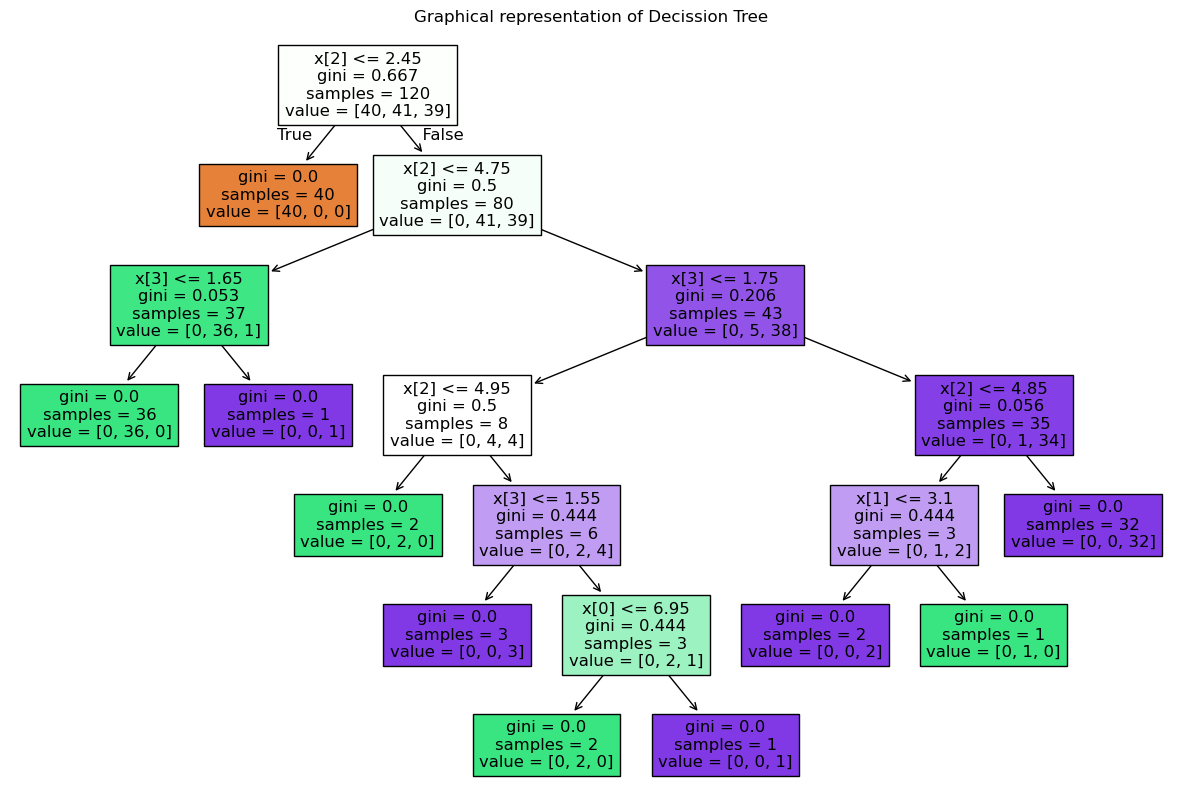

In [12]:
from sklearn import tree
plt.figure(figsize=(15, 10))
tree.plot_tree(tree_classifier, filled=True)
plt.title("Graphical representation of Decission Tree")
plt.savefig("Tree.png")
plt.show()

In [13]:
y_pred = tree_classifier.predict(x_test)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [15]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("accurecy - ", accuracy_score(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

accurecy -  1.0
